In [1]:
# Imports
import pandas as pd
import numpy as np
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')
os.chdir('..')

from src.utils.config_loader import load_config
from src.utils.visualization import *
from src.utils.eda_summary import *
from src.data_pipeline.preprocess import *
from src.data_pipeline.features import *


config = load_config("configs/data_config.yaml")
print("Imports done")

Imports done


In [2]:
import pyarrow.parquet as pq

# Load Ratings + Metadata
raw_path = config['paths']['raw_data']

pf_ratings = pq.ParquetFile(raw_path + "Electronics_ratings.parquet")
df_ratings = next(pf_ratings.iter_batches(batch_size=1_000_000)).to_pandas()

pf_meta = pq.ParquetFile(raw_path + "Electronics_metadata.parquet")
df_meta = next(pf_meta.iter_batches(batch_size=1_000_000)).to_pandas()

print(f"Ratings shape:  {df_ratings.shape}")
print(f"Metadata shape: {df_meta.shape}")

print(f"\nRatings columns:  {df_ratings.columns.tolist()}")
print(f"Metadata columns: {df_meta.columns.tolist()}")

Ratings shape:  (1000000, 10)
Metadata shape: (1000000, 9)

Ratings columns:  ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Metadata columns: ['parent_asin', 'title', 'description', 'features', 'categories', 'price', 'store', 'average_rating', 'rating_number']


---
## Ratings EDA

**Dataset:** Amazon Electronics Reviews 2023  
**Shape:**  Sample 1,000,000  rows × 10 columns  
**Source:** McAuley Lab, UCSD

This section explores the ratings dataset in depth, covering missing values, 
distributions, user/item activity patterns, sparsity, time trends, 
correlations, text analysis, user segmentation, and spam detection.

---

In [ ]:

df_ratings = replace_none_strings(df_ratings, columns=['title', 'text'])

[INFO] Replaced None strings in: ['title', 'text']


In [ ]:
missing_summary = summarize_missing_values(df_ratings)

print(f"Total rows: {missing_summary['total_rows']:,}")
print(f"Overall completeness: {missing_summary['overall_completeness']}%")
print(f"\nColumns with missing values:")
for col, info in missing_summary['columns_missing'].items():
    print(f"  {col}: {info['count']:,} ({info['percentage']}%)")

Total rows: 1,000,000
Overall completeness: 100.0%

Columns with missing values:
  title: 90 (0.01%)
  text: 124 (0.01%)


[INFO] Figure saved to docs/figures/01_rating_distribution.png


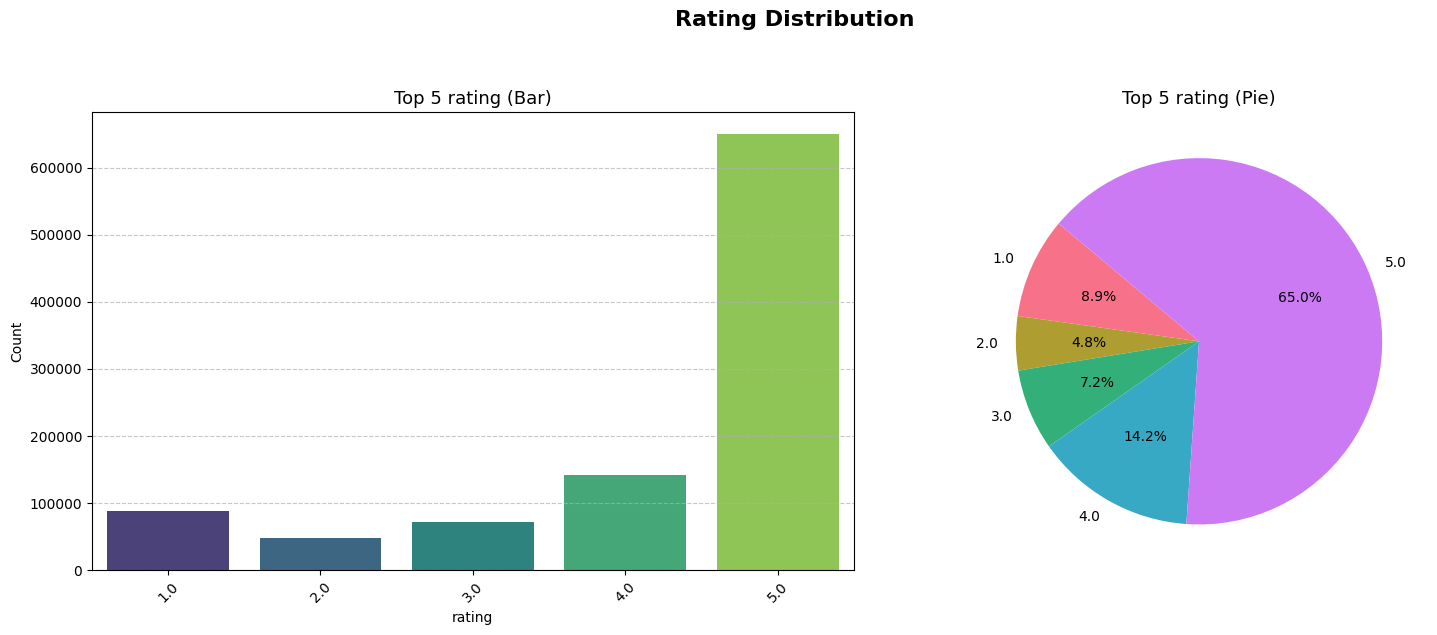

In [ ]:
plot_categorical_overview(
    df_ratings, 
    column='rating', 
    title='Rating Distribution',
    top_n=5,
    sort_by_index=True,   
    save_path='docs/figures/01_rating_distribution.png'
)

In [ ]:
df_ratings = df_ratings.drop(columns='images')

In [ ]:
duplicates = df_ratings.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({duplicates/len(df_ratings)*100:.3f}%)")

Duplicate rows: 2,495 (0.249%)


In [ ]:
user_activity = summarize_activity(df_ratings, group_col='user_id', count_col='asin')
print("=== User Activity ===")
for k, v in user_activity.items():
    print(f"  {k}: {v}")

item_activity = summarize_activity(df_ratings, group_col='asin', count_col='user_id')
print("\n=== Item Activity ===")
for k, v in item_activity.items():
    print(f"  {k}: {v}")

=== User Activity ===
  group_col: user_id
  n_groups: 185242
  mean_activity: 5.4
  median_activity: 3.0
  std_activity: 11.29
  min_activity: 1
  max_activity: 1034
  total_interactions: 1000000

=== Item Activity ===
  group_col: asin
  n_groups: 317522
  mean_activity: 3.15
  median_activity: 1.0
  std_activity: 19.85
  min_activity: 1
  max_activity: 5205
  total_interactions: 1000000


In [ ]:
user_long_tail = detect_long_tail(df_ratings, group_col='user_id', threshold_percentile=80)
print("\n")
item_long_tail = detect_long_tail(df_ratings, group_col='asin', threshold_percentile=80)

[INFO] Long-tail analysis: 69315 items (37.42%) account for 80.0% of interactions


[INFO] Long-tail analysis: 120561 items (37.97%) account for 80.0% of interactions


[INFO] Figure saved to docs/figures/02_user_activity_distribution.png


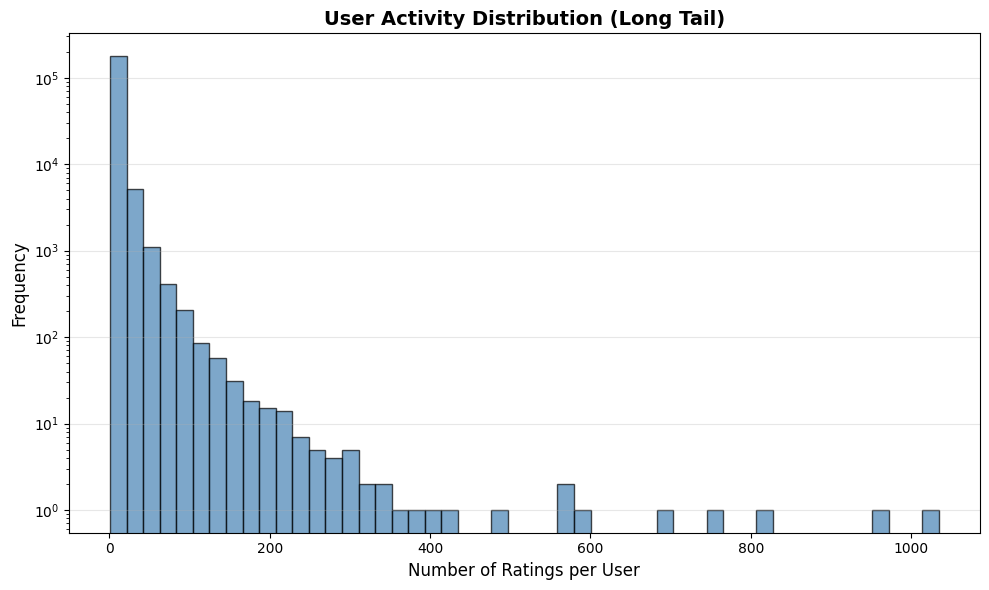

[INFO] Figure saved to docs/figures/03_item_activity_distribution.png


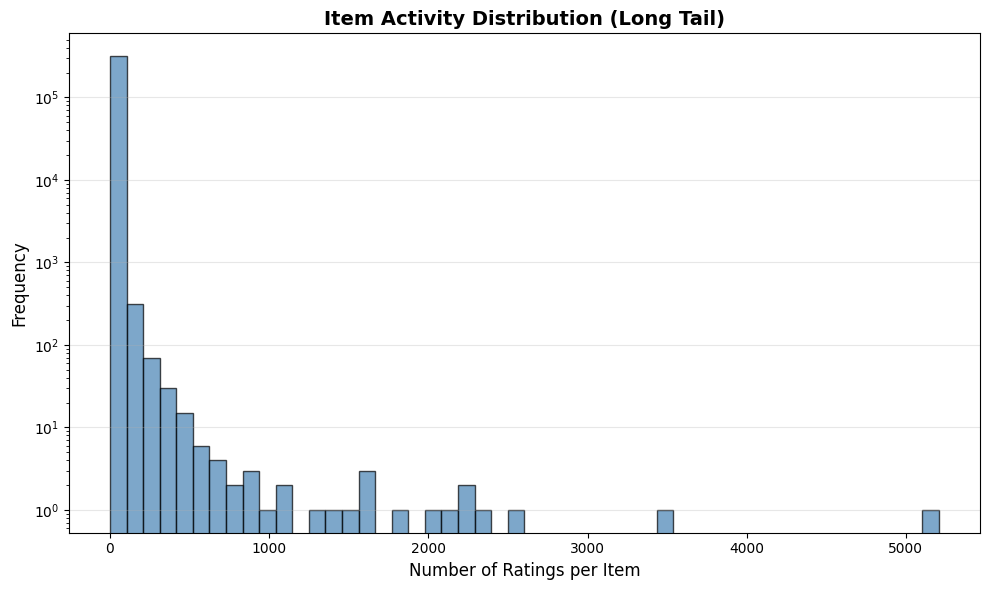

In [ ]:
plot_histogram(
    df_ratings.groupby('user_id').size().reset_index(name='count'),
    column='count',
    title='User Activity Distribution (Long Tail)',
    xlabel='Number of Ratings per User',
    bins=50,
    log_scale=True,
    save_path='docs/figures/02_user_activity_distribution.png'
)

plot_histogram(
    df_ratings.groupby('asin').size().reset_index(name='count'),
    column='count',
    title='Item Activity Distribution (Long Tail)',
    xlabel='Number of Ratings per Item',
    bins=50,
    log_scale=True,
    save_path='docs/figures/03_item_activity_distribution.png'
)

[INFO] Figure saved to docs/figures/04_rating_boxplot.png


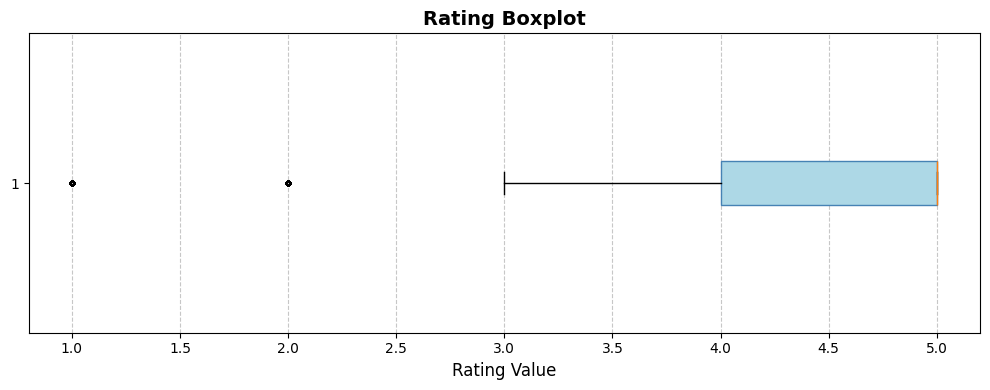

[INFO] Figure saved to docs/figures/05_helpful_vote_boxplot.png


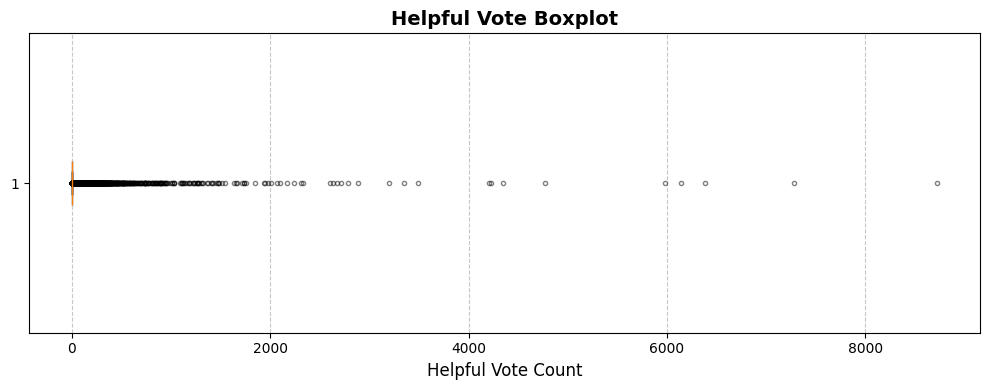

In [ ]:
plot_boxplot(
    df_ratings, 
    column='rating',
    title='Rating Boxplot',
    xlabel='Rating Value',
    save_path='docs/figures/04_rating_boxplot.png'
)

plot_boxplot(
    df_ratings, 
    column='helpful_vote',
    title='Helpful Vote Boxplot',
    xlabel='Helpful Vote Count',
    save_path='docs/figures/05_helpful_vote_boxplot.png'
)

[INFO] Converted 'timestamp' to datetime format
[INFO] Figure saved to docs/figures/06_time_analysis.png


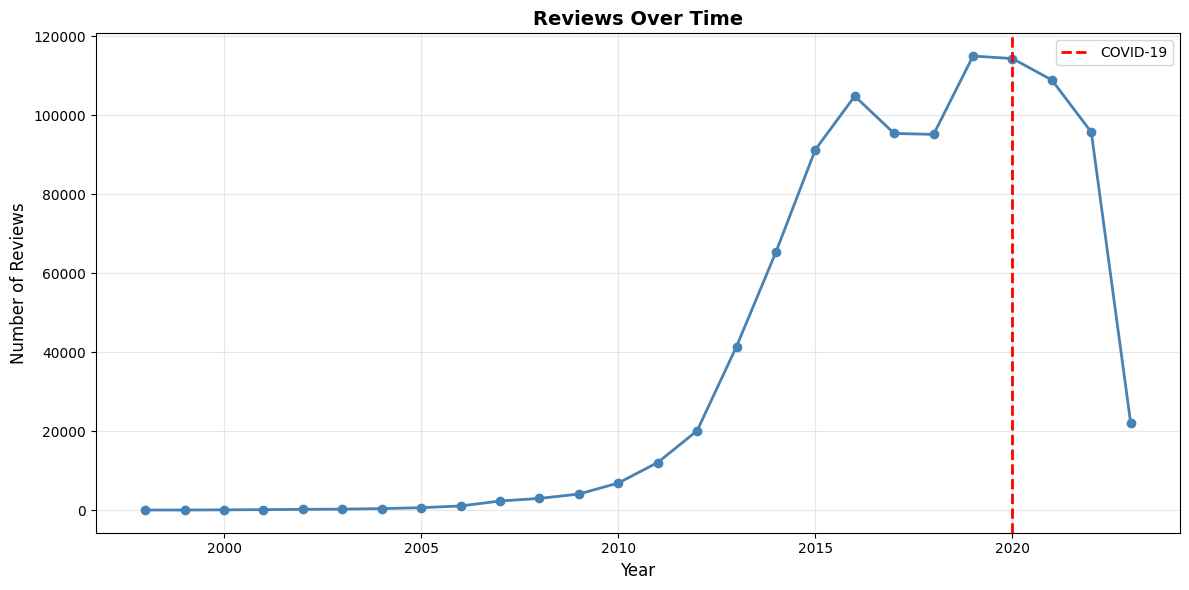

In [ ]:
df_ratings = convert_timestamp(df_ratings)

reviews_per_year = df_ratings['timestamp'].dt.year.value_counts().sort_index().reset_index()
reviews_per_year.columns = ['year', 'count']

plot_lineplot(
    reviews_per_year,
    x_col='year',
    y_col='count',
    title='Reviews Over Time',
    xlabel='Year',
    ylabel='Number of Reviews',
    marker_year=2020,
    marker_label='COVID-19',
    save_path='docs/figures/06_time_analysis.png'
)

In [ ]:
print(f"Earliest date: {df_ratings['timestamp'].min()}")
print(f"Latest date:   {df_ratings['timestamp'].max()}")

Earliest date: 1998-03-03 12:17:02
Latest date:   2023-03-20 20:48:25.319000


In [ ]:
test_data = df_ratings[df_ratings['timestamp'].dt.year >= 2022]
print(test_data['timestamp'].dt.year.value_counts().sort_index())

timestamp
2022    95714
2023    21923
Name: count, dtype: int64


### Insight — Time Analysis

The visible drop in reviews during 2023 is **not a real decline in user activity**.

- The dataset's last recorded timestamp is **March 20, 2023** — meaning the data collection 
  was cut off mid-year, not that activity stopped.
- Monthly average comparison confirms this:
  - 2022: ~7,976 reviews/month (full year, 95,714 total)
  - 2023: ~8,769 reviews/month (partial year, 21,923 total — only ~2.5 months)
- The 2023 monthly rate is actually **higher** than 2022, confirming continued growth 
  up until the data snapshot was taken.

**Implication for Train/Val/Test split:** The current Test set (2022 onward) remains 
statistically valid — there is no artificial distortion in the data distribution, 
only a natural truncation at the collection date.

In [ ]:
sparsity_result = calculate_sparsity(df_ratings, user_col='user_id', item_col='parent_asin')

print(f"Unique users: {sparsity_result['n_users']:,}")
print(f"Unique items: {sparsity_result['n_items']:,}")
print(f"Total interactions: {sparsity_result['n_interactions']:,}")
print(f"Possible interactions: {sparsity_result['possible_interactions']:,}")
print(f"Sparsity: {sparsity_result['sparsity_percentage']}%")
print(f"Density: {sparsity_result['density_percentage']}%")

Unique users: 185,242
Unique items: 271,211
Total interactions: 1,000,000
Possible interactions: 50,239,668,062
Sparsity: 100.0%
Density: 0.0%


[INFO] Figure saved to docs/figures/07_top_items.png


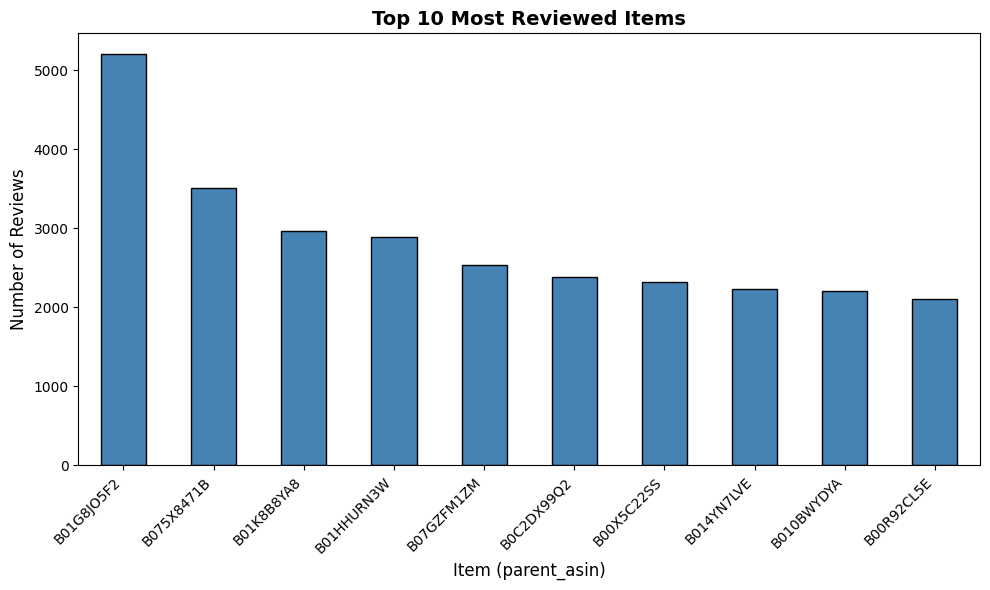

In [ ]:
top_items = df_ratings['parent_asin'].value_counts().head(10).reset_index()
top_items.columns = ['parent_asin', 'count']

plot_bar_distribution(
    top_items,
    column='parent_asin',
    value_col='count',
    pre_aggregated=True,
    title='Top 10 Most Reviewed Items',
    xlabel='Item (parent_asin)',
    ylabel='Number of Reviews',
    save_path='docs/figures/07_top_items.png'
)

[INFO] Figure saved to docs/figures/08_correlation_heatmap.png


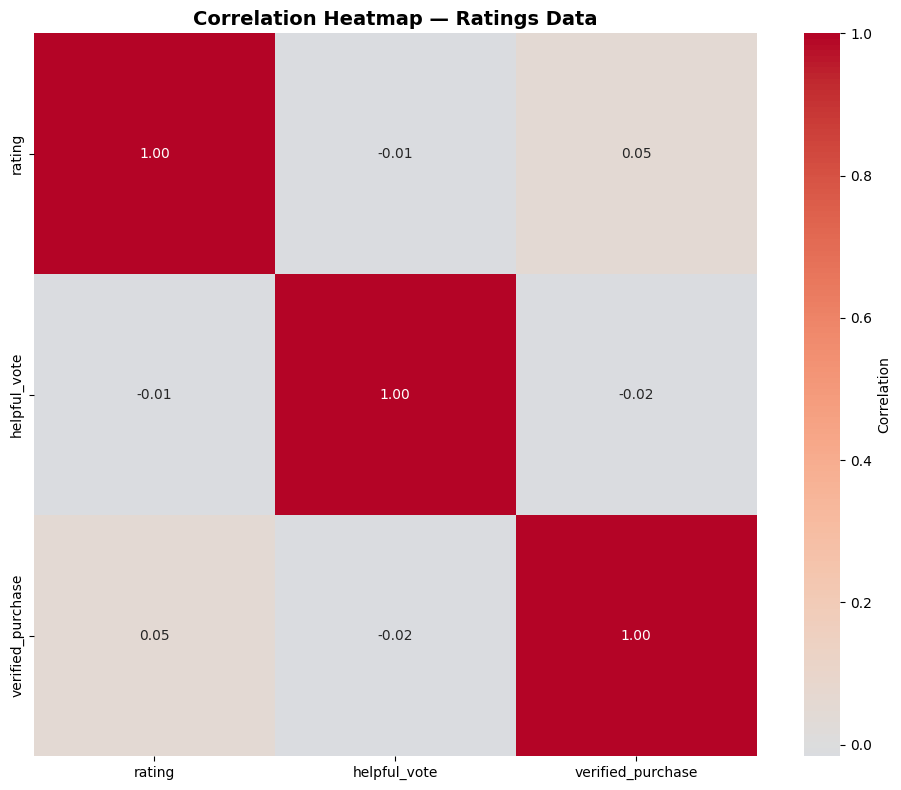

In [ ]:
corr_df = df_ratings[['rating', 'helpful_vote', 'verified_purchase']].copy()
corr_df['verified_purchase'] = corr_df['verified_purchase'].astype(int)

plot_heatmap(
    corr_df,
    title='Correlation Heatmap — Ratings Data',
    save_path='docs/figures/08_correlation_heatmap.png'
)

[INFO] Figure saved to docs/figures/09_verified_vs_unverified.png


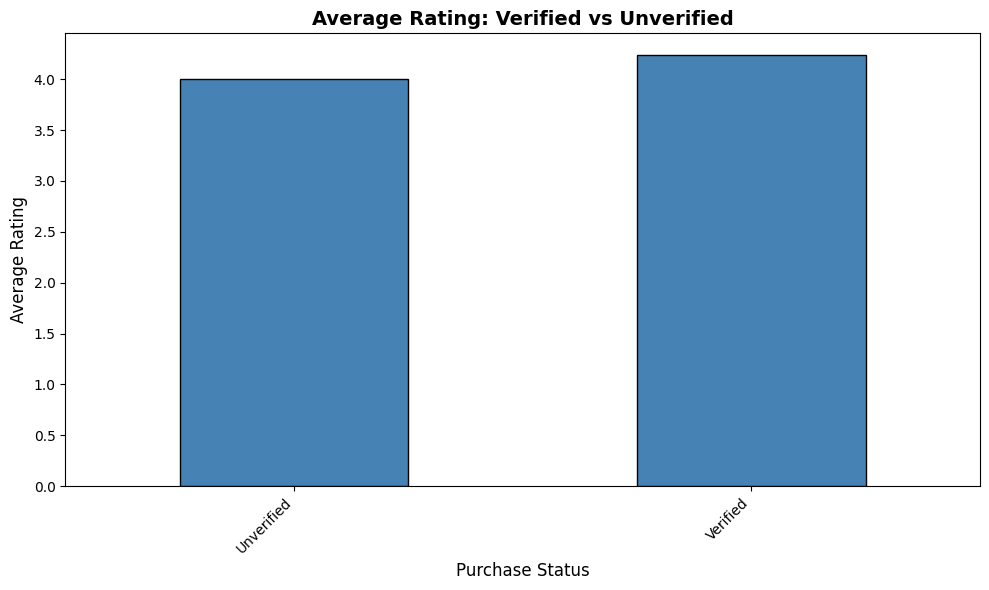

In [ ]:
df_ratings['verified_purchase'] = df_ratings['verified_purchase'].astype(int)
verified_comparison = df_ratings.groupby('verified_purchase')['rating'].mean().reset_index()
verified_comparison.columns = ['verified_purchase', 'avg_rating']
verified_comparison['verified_purchase'] = verified_comparison['verified_purchase'].map({0: 'Unverified', 1: 'Verified'})

plot_bar_distribution(
    verified_comparison,
    column='verified_purchase',
    value_col='avg_rating',
    pre_aggregated=True,
    title='Average Rating: Verified vs Unverified',
    xlabel='Purchase Status',
    ylabel='Average Rating',
    save_path='docs/figures/09_verified_vs_unverified.png'
)

[INFO] Figure saved to docs/figures/10_text_length_distribution.png


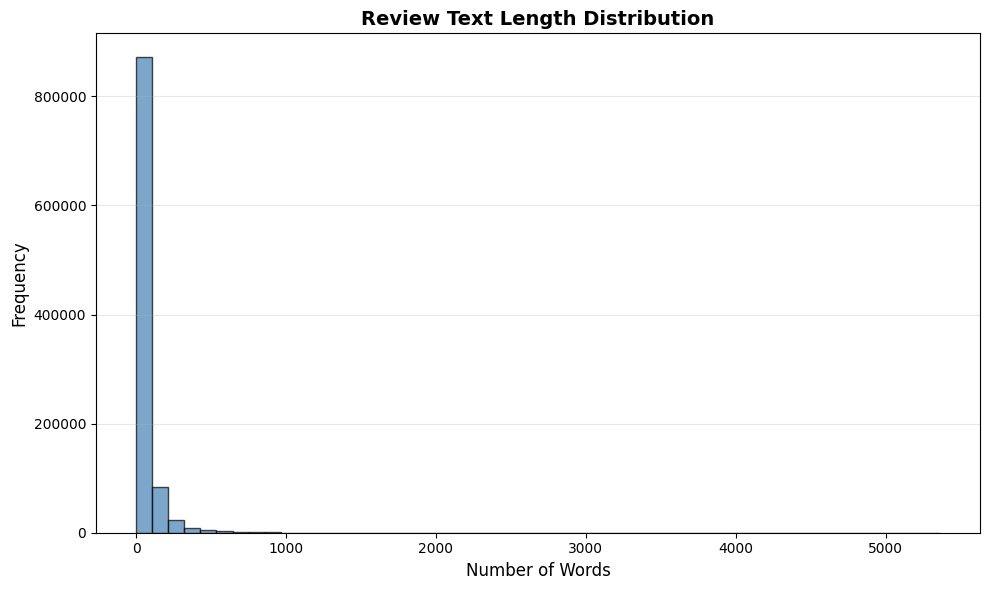


=== Text Length Stats ===
  column: word_count
  missing_count: 0
  missing_percentage: 0.0
  count: 999876
  mean: 54.8053
  median: 27.0
  std: 93.2872
  min: 0
  q25: 10.0
  q75: 62.0
  max: 5361
  skewness: 7.3868
  kurtosis: 135.2598


In [ ]:
word_counts = df_ratings['text'].dropna().str.split().str.len()
word_counts_df = pd.DataFrame({'word_count': word_counts.values})

plot_histogram(
    word_counts_df,
    column='word_count',
    title='Review Text Length Distribution',
    xlabel='Number of Words',
    bins=50,
    save_path='docs/figures/10_text_length_distribution.png'
)

text_stats = summarize_distribution(word_counts_df, 'word_count')
print(f"\n=== Text Length Stats ===")
for k, v in text_stats.items():
    print(f"  {k}: {v}")

[INFO] Figure saved to docs/figures/11_user_segmentation.png


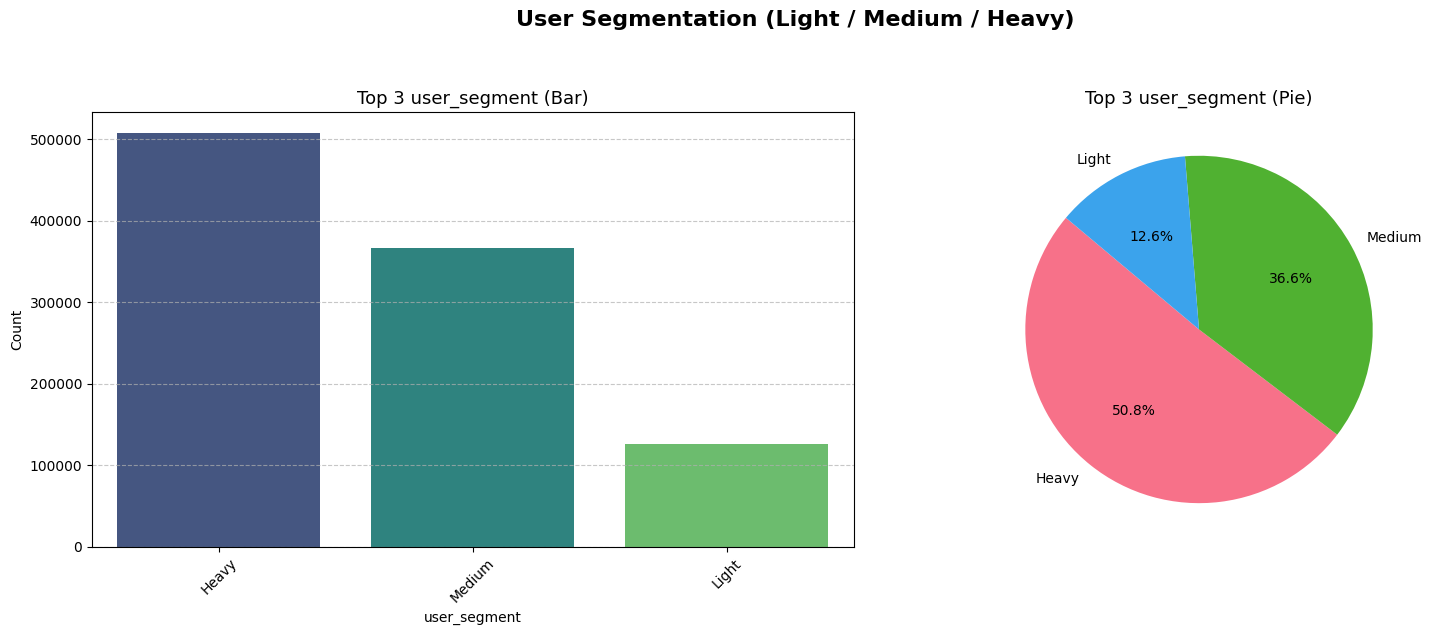

user_segment
Heavy     507520
Medium    366497
Light     125983
Name: count, dtype: int64


In [ ]:
user_counts = df_ratings.groupby('user_id').size()
user_segment = pd.cut(
    df_ratings['user_id'].map(user_counts),
    bins=[0, 2, 10, float('inf')],
    labels=['Light', 'Medium', 'Heavy']
)
segment_df = pd.DataFrame({'user_segment': user_segment})

plot_categorical_overview(
    segment_df,
    column='user_segment',
    title='User Segmentation (Light / Medium / Heavy)',
    top_n=3,
    sort_by_index=False,
    save_path='docs/figures/11_user_segmentation.png'
)

print(segment_df['user_segment'].value_counts())

[INFO] Figure saved to docs/figures/12_spam_detection.png


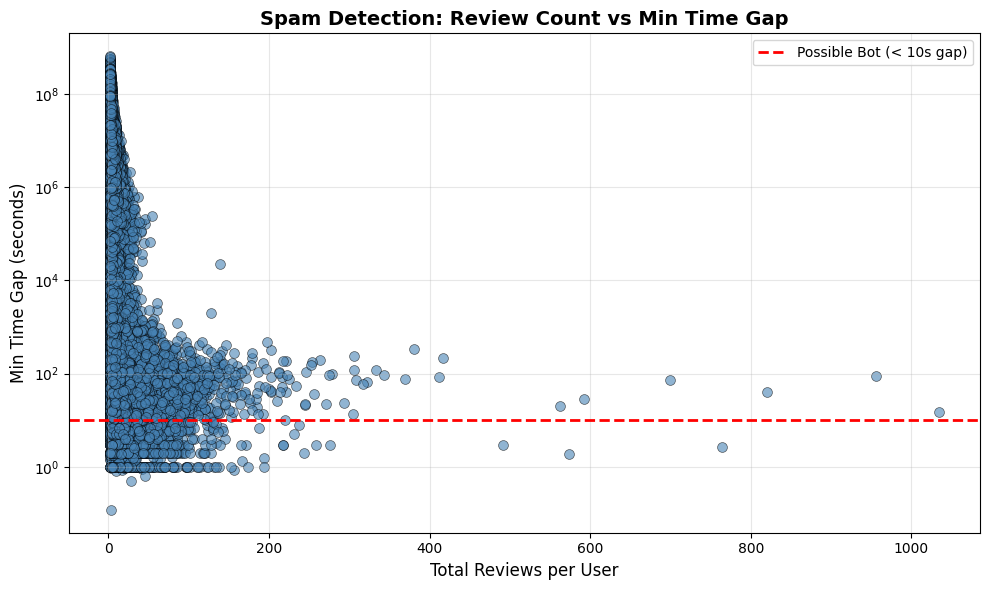

In [ ]:
df_sorted = df_ratings.sort_values(['user_id', 'timestamp'])
df_sorted['time_diff'] = df_sorted.groupby('user_id')['timestamp'].diff().dt.total_seconds()

user_spam_stats = df_sorted.groupby('user_id').agg(
    total_ratings=('rating', 'count'),
    min_time_gap=('time_diff', 'min')
).reset_index()

plot_scatterplot(
    user_spam_stats,
    x_col='total_ratings',
    y_col='min_time_gap',
    title='Spam Detection: Review Count vs Min Time Gap',
    xlabel='Total Reviews per User',
    ylabel='Min Time Gap (seconds)',
    threshold_y=10,
    threshold_label='Possible Bot (< 10s gap)',
    log_scale_y=True,
    save_path='docs/figures/12_spam_detection.png'
)

In [ ]:
# ============ FUTURE IMPROVEMENTS ============
# 1. ML-based spam detection model
# 2. Advanced feedback loop integration  
# 3. Cross-domain recommendations
# 4. A/B Testing framework
# =============================================

---
## Metadata EDA

**Dataset:** Amazon Electronics Metadata 2023  
**Shape:** 1,000,000 rows × 9 columns  
**Columns:** parent_asin, title, description, features, categories, price, store, average_rating, rating_number

This section explores the metadata dataset, covering missing values (especially price),
text fields (description, features), category structure, store distribution, 
and store tier classification.

---

In [ ]:
missing_meta = summarize_missing_values(df_meta)

print(f"Total rows: {missing_meta['total_rows']:,}")
print(f"Overall completeness: {missing_meta['overall_completeness']}%")
print(f"\nColumns with missing values:")
for col, info in missing_meta['columns_missing'].items():
    print(f"  {col}: {info['count']:,} ({info['percentage']}%)")

Total rows: 1,000,000
Overall completeness: 92.71%

Columns with missing values:
  price: 650,124 (65.01%)
  store: 5,709 (0.57%)


=== Price Distribution Stats ===
  column: price
  missing_count: 650124
  missing_percentage: 65.01
  count: 349876
  mean: 92.4203
  median: 21.99
  std: 297.1314
  min: 0.0
  q25: 11.99
  q75: 59.95
  max: 24996.99
  skewness: 18.567
  kurtosis: 837.3482
[INFO] Figure saved to docs/figures/13_price_distribution.png


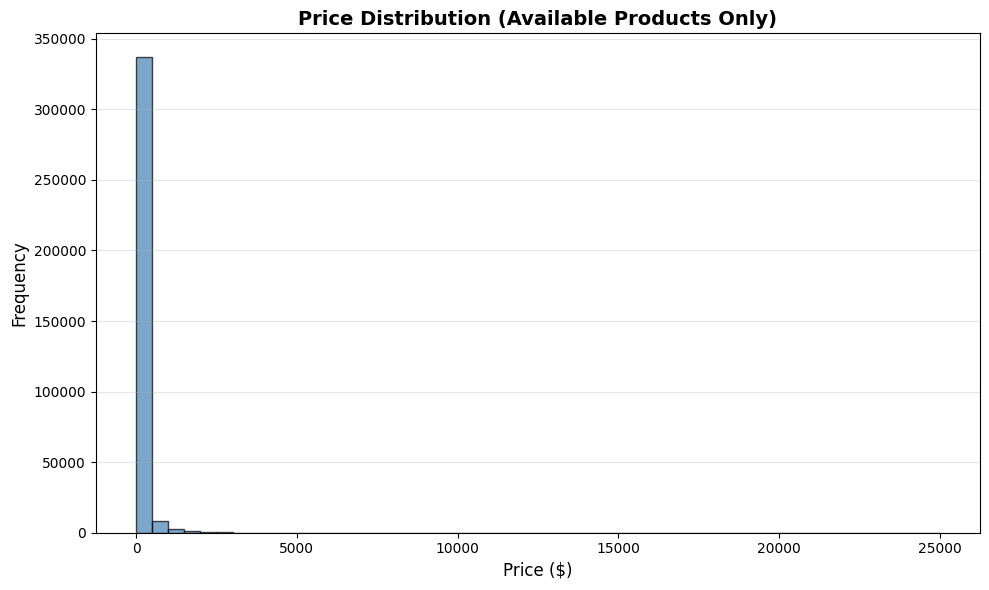

In [ ]:
price_stats = summarize_distribution(df_meta, 'price')
print("=== Price Distribution Stats ===")
for k, v in price_stats.items():
    print(f"  {k}: {v}")

plot_histogram(
    df_meta.dropna(subset=['price']),
    column='price',
    title='Price Distribution (Available Products Only)',
    xlabel='Price ($)',
    bins=50,
    save_path='docs/figures/13_price_distribution.png'
)

In [ ]:
empty_features = df_meta['features'].apply(
    lambda x: len(x) == 0
).sum()
print(f"Empty features: {empty_features:,} ({empty_features/len(df_meta)*100:.1f}%)")

Empty features: 254,554 (25.5%)


=== Category Depth Stats ===
  column: depth
  missing_count: 0
  missing_percentage: 0.0
  count: 1000000
  mean: 4.0301
  median: 4.0
  std: 1.515
  min: 0
  q25: 4.0
  q75: 5.0
  max: 7
  skewness: -1.3589
  kurtosis: 1.6736
[INFO] Figure saved to docs/figures/15_category_depth.png


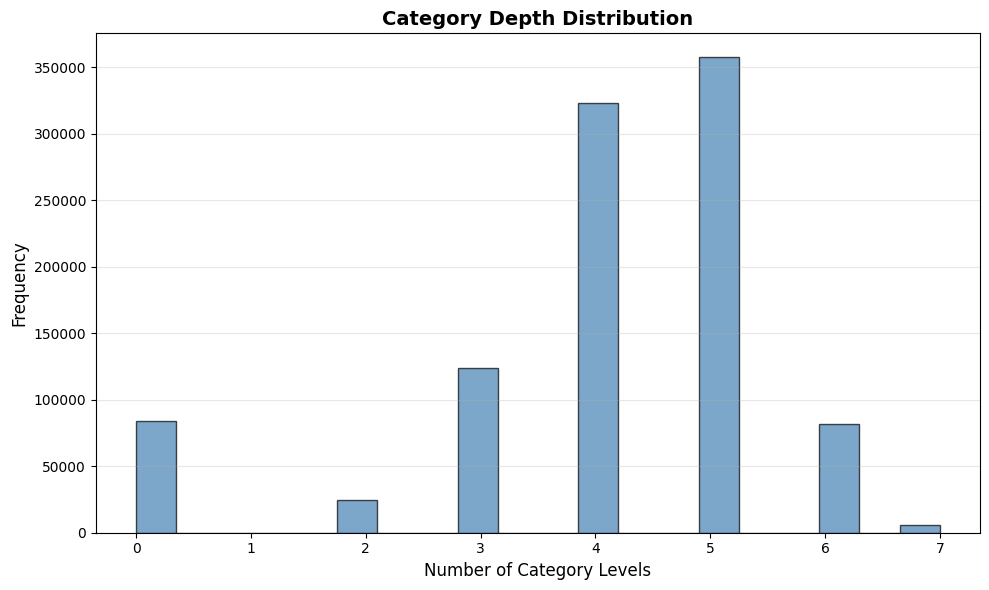

In [ ]:
cat_depth = df_meta['categories'].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
)
cat_depth_df = pd.DataFrame({'depth': cat_depth.values})

depth_stats = summarize_distribution(cat_depth_df, 'depth')
print("=== Category Depth Stats ===")
for k, v in depth_stats.items():
    print(f"  {k}: {v}")

plot_histogram(
    cat_depth_df,
    column='depth',
    title='Category Depth Distribution',
    xlabel='Number of Category Levels',
    bins=20,
    save_path='docs/figures/15_category_depth.png'
)

In [ ]:
# Store stats + Long Tail
store_stats = summarize_activity(
    df_meta, 
    group_col='store', 
    count_col='parent_asin'
)
print("=== Store Activity Stats ===")
for k, v in store_stats.items():
    print(f"  {k}: {v}")

store_long_tail = detect_long_tail(df_meta, group_col='store', threshold_percentile=80)
print("\n=== Store Long Tail ===")
for k, v in store_long_tail.items():
    print(f"  {k}: {v}")

=== Store Activity Stats ===
  group_col: store
  n_groups: 110734
  mean_activity: 8.98
  median_activity: 2.0
  std_activity: 93.26
  min_activity: 1
  max_activity: 18055
  total_interactions: 994291
[INFO] Long-tail analysis: 15532 items (14.03%) account for 80.0% of interactions

=== Store Long Tail ===
  group_col: store
  total_groups: 110734
  head_groups: 15532
  tail_groups: 95202
  head_percentage: 14.03
  tail_percentage: 85.97
  head_interactions: 795426
  tail_interactions: 198865
  head_coverage_percentage: 80.0


[INFO] Store tier distribution:
store_tier
Trusted         926204
Premium          44687
Small Seller     23400
Name: count, dtype: int64
[INFO] Figure saved to docs/figures/16_store_tier_distribution.png


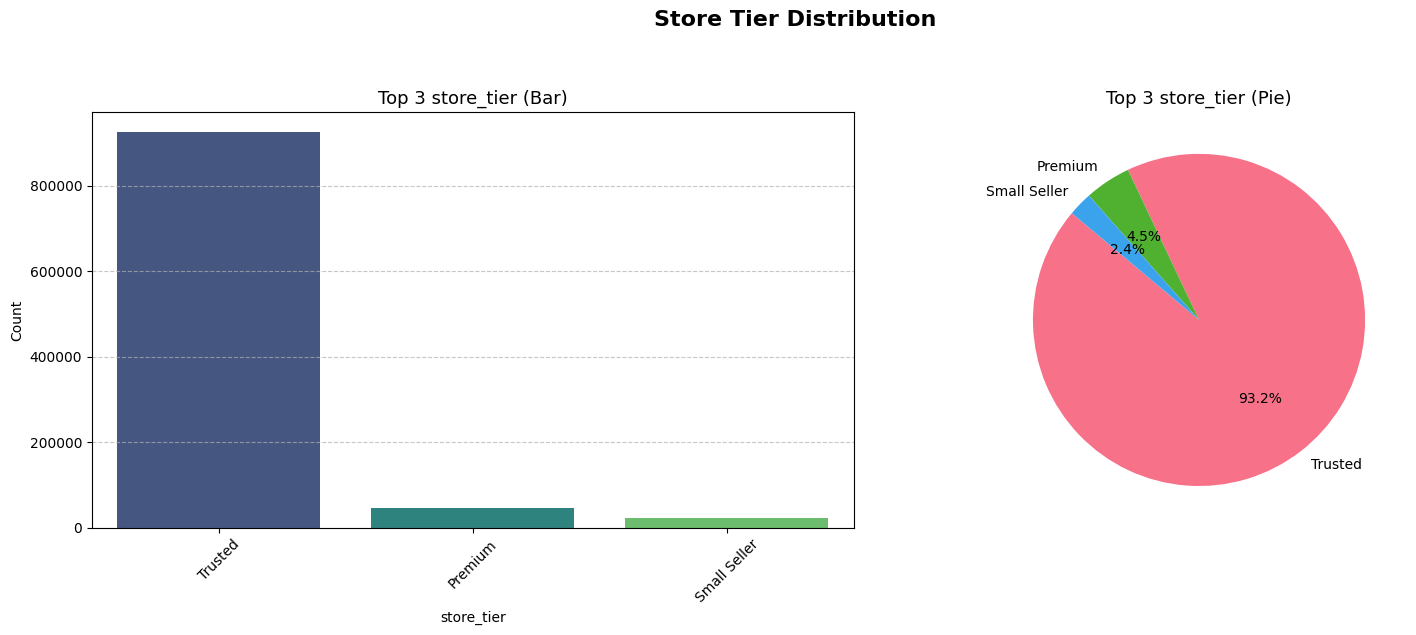

In [ ]:
df_meta = add_store_tier(df_meta)

plot_categorical_overview(
    df_meta.dropna(subset=['store_tier']),  # ← شيل الـ NaN الأول
    column='store_tier',
    title='Store Tier Distribution',
    top_n=3,
    sort_by_index=False,
    save_path='docs/figures/16_store_tier_distribution.png'
)

=== Average Rating Stats (Metadata) ===
  column: average_rating
  missing_count: 0
  missing_percentage: 0.0
  count: 1000000
  mean: 4.0293
  median: 4.2
  std: 0.7709
  min: 1.0
  q25: 3.7
  q75: 4.5
  max: 5.0
  skewness: -1.4061
  kurtosis: 2.9999
[INFO] Figure saved to docs/figures/17_avg_rating_distribution.png


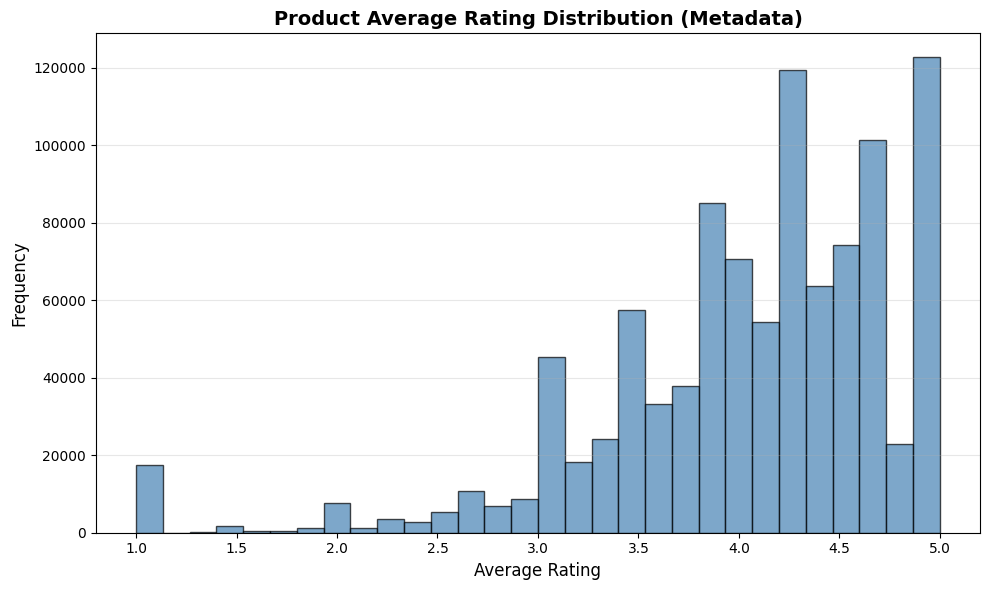


=== Rating Number Stats (Metadata) ===
  column: rating_number
  missing_count: 0
  missing_percentage: 0.0
  count: 1000000
  mean: 226.7094
  median: 16.0
  std: 2926.3284
  min: 1
  q25: 4.0
  q75: 64.0
  max: 1034896
  skewness: 121.3597
  kurtosis: 28256.9002


In [ ]:
# Average Rating Distribution
rating_stats = summarize_distribution(df_meta, 'average_rating')
print("=== Average Rating Stats (Metadata) ===")
for k, v in rating_stats.items():
    print(f"  {k}: {v}")

plot_histogram(
    df_meta,
    column='average_rating',
    title='Product Average Rating Distribution (Metadata)',
    xlabel='Average Rating',
    bins=30,
    save_path='docs/figures/17_avg_rating_distribution.png'
)

# Rating Number Distribution
rating_num_stats = summarize_distribution(df_meta, 'rating_number')
print("\n=== Rating Number Stats (Metadata) ===")
for k, v in rating_num_stats.items():
    print(f"  {k}: {v}")

---
## Combined Insights & Key Findings

### 1. Class Imbalance
- 65% of all ratings are 5-star → models may be biased toward high-rated items
- Implication: consider weighted sampling or adjusted metrics during training

### 2. Long Tail Distribution (Universal Pattern)
- Users: top 37% account for 80% of interactions
- Items: top 38% account for 80% of interactions  
- Stores: top 14% account for 80% of products
- Implication: Cold Start Problem is a core challenge — new users/items will have very few interactions

### 3. Extreme Sparsity
- 185,242 users × 271,211 items = 50.2 billion possible interactions
- Only 1,000,000 actual interactions = 99.998% sparsity
- Implication: Memory-Based CF (KNN) will struggle → Matrix Factorization (SVD/ALS) is required

### 4. Data Collection Cutoff
- Dataset ends March 20, 2023 — NOT a real decline in activity
- Monthly rate in 2023 (~8,769/month) is higher than 2022 (~7,976/month)
- Implication: Time-based split (Train < 2021 / Val = 2021 / Test ≥ 2022) is statistically valid

### 5. Spam & Bot Activity
- Detected users with review gaps < 10 seconds → automated behavior
- Spam filter: max 5 reviews/day OR min 10-second gap between reviews
- Implication: Spam removal essential to prevent model poisoning

### 6. Price Data Gap
- 65% of metadata products have no price information
- Available prices show extreme Long Tail ($0 → $24,997, median = $22)
- Implication: Price usable as optional feature in Content-Based/RAG, not as required field

### 7. Rich Metadata for RAG
- description: detailed text, ideal for semantic embeddings
- features: available for 74.5% of products (25.5% empty lists)
- categories: hierarchical (avg 4 levels deep), structured for filtering
- Implication: Strong foundation for RAG system and Content-Based Filtering

### 8. Store Quality Signal
- 110,734 unique stores with extreme Long Tail
- store_tier (Premium/Trusted/Small Seller) provides a reliable quality signal
- Implication: store_tier can be used as a ranking/reranking feature in Hybrid Model

---